<a id="import"></a>
# <center>Import Need Modules</center>

In [1]:
# Google Colab specific imports
from google.colab import drive
# Core libraries
import numpy as np
import pandas as pd
import os
import time
import shutil

# Suppress TensorFlow warnings
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'

# Visualization
import matplotlib.pyplot as plt
import cv2
import seaborn as sns
sns.set_style('darkgrid')

# Machine Learning
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.model_selection import train_test_split

# TensorFlow and Keras
import tensorflow as tf
from tensorflow import keras

# Enable mixed precision for faster training on GPU
from tensorflow.keras import mixed_precision
policy = mixed_precision.Policy('float32')
mixed_precision.set_global_policy(policy)
print('Compute dtype: %s' % policy.compute_dtype)
print('Variable dtype: %s' % policy.variable_dtype)
# Keras modules
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.layers import Dense, Activation, Dropout, Conv2D, MaxPooling2D, BatchNormalization
from tensorflow.keras.optimizers import Adam, Adamax
from tensorflow.keras.metrics import categorical_crossentropy
from tensorflow.keras import regularizers
from tensorflow.keras.models import Model

# Check GPU availability
print("GPU Available:", tf.config.list_physical_devices('GPU'))
if tf.config.list_physical_devices('GPU'):
    print("GPU detected! Training will be fast.")
else:
    print("No GPU detected. Training will be slow.")

Compute dtype: float32
Variable dtype: float32
GPU Available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
GPU detected! Training will be fast.


### The size of the images are very large. If you try to use the full image size training will take a very long time. Therefore you
### want to reduce the image size. However if you include resizing of images as part of training it requires each image to be repeatedly
### resized in each epoch. This also make the training times to be large. It is more efficient to resize all the images FIRST and save them.
### Then use these images for training.

<a id="resize"></a>
# <center>Resize all images and save to the working directory</center>

In [2]:
# Mount Google Drive
drive.mount('/content/drive')
start_time=time.time()
sdir = '/content/drive/MyDrive/dataset_train'
working_dir = '/content/cauliflower_training/'
img_height = 300
img_width = 300

# Create working directory first
os.makedirs(working_dir, exist_ok=True)

save_path = os.path.join(working_dir, 'cali')

if os.path.isdir(save_path):
    shutil.rmtree(save_path) # if the directory exists remove it

os.makedirs(save_path, exist_ok=True)  # Changed from os.mkdir() to os.makedirs()

classlist = sorted(os.listdir(sdir))
for klass in classlist:
    classpath = os.path.join(sdir, klass)
    if not os.path.isdir(classpath):  # skip if not a directory
        continue
    print('processing ', klass,  ' class')
    class_dest_path = os.path.join(save_path, klass)
    os.makedirs(class_dest_path, exist_ok=True)  # Changed here too
    flist = os.listdir(classpath)
    for f in flist:
        fpath = os.path.join(classpath,f)
        f_dest_path = os.path.join(class_dest_path, f)
        try: # make sure images are correct image files
            img = cv2.imread(fpath)
            img = cv2.resize(img, (img_height, img_width))
            cv2.imwrite(f_dest_path, img)
        except:
            print('Image ', fpath, ' is an invalid image file')

tr_duration = time.time() - start_time
hours = tr_duration // 3600
minutes = (tr_duration - (hours * 3600)) // 60
seconds = tr_duration - ((hours * 3600) + (minutes * 60))
msg = f'resizing elapsed time was {str(hours)} hours, {minutes:4.1f} minutes, {seconds:4.2f} seconds)'
print(msg, flush=True)

Mounted at /content/drive
processing  Alternaria Leaf Spot  class
processing  Bacterial Soft Rot  class
processing  Black Rot  class
processing  Downy Mildew  class
processing  Healthy  class
resizing elapsed time was 0.0 hours,  6.0 minutes, 16.35 seconds)


<a id="makedf"></a>
# <center>Read in resized images and create a dataframe of image paths and class labels</center>

In [3]:
def make_df(save_path):
    classlist=os.listdir(save_path)
    filepaths=[]
    labels=[]
    for klass in classlist:
        classpath=os.path.join(save_path, klass)
        flist=os.listdir(classpath)
        for f in flist:
            fpath=os.path.join(classpath,f)
            filepaths.append(fpath)
            labels.append(klass)
    Fseries=pd.Series(filepaths, name='filepaths')
    Lseries=pd.Series(labels, name='labels')
    df=pd.concat([Fseries, Lseries], axis=1)
    train_df, dummy_df=train_test_split(df, train_size=.8, shuffle=True, random_state=123, stratify=df['labels'])
    valid_df, test_df=train_test_split(dummy_df,train_size=.5, shuffle=True, random_state=123, stratify=dummy_df['labels'])
    print('train_df lenght: ', len(train_df), '  test_df length: ', len(test_df), '  valid_df length: ', len(valid_df))
    # get the number of classes and the images count for each class in train_df
    classes=sorted(list(train_df['labels'].unique()))
    class_count = len(classes)
    print('The number of classes in the dataset is: ', class_count)
    groups=train_df.groupby('labels')
    print('{0:^30s} {1:^13s}'.format('CLASS', 'IMAGE COUNT'))
    countlist=[]
    classlist=[]
    for label in sorted(list(train_df['labels'].unique())):
        group=groups.get_group(label)
        countlist.append(len(group))
        classlist.append(label)
        print('{0:^30s} {1:^13s}'.format(label, str(len(group))))

    # get the classes with the minimum and maximum number of train images
    max_value=np.max(countlist)
    max_index=countlist.index(max_value)
    max_class=classlist[max_index]
    min_value=np.min(countlist)
    min_index=countlist.index(min_value)
    min_class=classlist[min_index]
    print(max_class, ' has the most images= ',max_value, ' ', min_class, ' has the least images= ', min_value)
    # lets get the average height and width of a sample of the train images
    ht=0
    wt=0
    # select 100 random samples of train_df
    train_df_sample=train_df.sample(n=100, random_state=123,axis=0)
    for i in range (len(train_df_sample)):
        fpath=train_df_sample['filepaths'].iloc[i]
        img=plt.imread(fpath)
        shape=img.shape
        ht += shape[0]
        wt += shape[1]
    print('average height= ', ht//100, ' average width= ', wt//100, 'aspect ratio= ', ht/wt)
    return train_df, test_df, valid_df, classes
train_df, test_df, valid_df, classes = make_df(save_path)
class_count=len(classes)

train_df lenght:  6203   test_df length:  776   valid_df length:  775
The number of classes in the dataset is:  5
            CLASS               IMAGE COUNT 
     Alternaria Leaf Spot          1206     
      Bacterial Soft Rot           1121     
          Black Rot                 627     
         Downy Mildew               721     
           Healthy                 2528     
Healthy  has the most images=  2528   Black Rot  has the least images=  627
average height=  300  average width=  300 aspect ratio=  1.0


<a id="balancing_dataset"></a>
# <center>Balancing Dataset</center>

In [4]:
# IMPROVED BALANCE FUNCTION - Now handles both upsampling AND downsampling
def balance(df, n, working_dir, img_size):
    """
    Balance dataset to exactly n samples per class by:
    1. Downsampling majority classes to n
    2. Augmenting minority classes up to n
    """
    df = df.copy()
    print(f'Initial dataframe length: {len(df)}')
    print('\n=== Initial Class Distribution ===')
    initial_dist = df['labels'].value_counts().sort_index()
    print(initial_dist)

    # STEP 1: DOWNSAMPLE majority classes first
    print(f'\n=== Step 1: Downsampling classes with > {n} samples ===')
    balanced_frames = []
    for label in sorted(df['labels'].unique()):
        class_df = df[df['labels'] == label]
        count = len(class_df)

        if count > n:
            class_df = class_df.sample(n=n, random_state=123)
            print(f'✓ Downsampled {label:30s} from {count:4d} to {n}')
        else:
            print(f'  Kept {label:30s} at {count:4d} samples (will augment later)')

        balanced_frames.append(class_df)

    df = pd.concat(balanced_frames, axis=0).reset_index(drop=True)
    print(f'\nAfter downsampling: {len(df)} total samples')

    # STEP 2: AUGMENT minority classes
    print(f'\n=== Step 2: Augmenting classes with < {n} samples ===')
    aug_dir = os.path.join(working_dir, 'aug')
    if os.path.isdir(aug_dir):
        shutil.rmtree(aug_dir)
    os.mkdir(aug_dir)

    for label in df['labels'].unique():
        dir_path = os.path.join(aug_dir, label)
        os.mkdir(dir_path)

    total_augmented = 0
    gen = ImageDataGenerator(
        horizontal_flip=True,
        rotation_range=20,
        width_shift_range=.2,
        height_shift_range=.2,
        zoom_range=.2
    )

    groups = df.groupby('labels')
    for label in sorted(df['labels'].unique()):
        group = groups.get_group(label)
        sample_count = len(group)

        if sample_count < n:
            delta = n - sample_count
            target_dir = os.path.join(aug_dir, label)
            print(f'✓ Creating {delta:3d} augmented images for {label:30s}')

            aug_gen = gen.flow_from_dataframe(
                group,
                x_col='filepaths',
                y_col=None,
                target_size=img_size,
                class_mode=None,
                batch_size=1,
                shuffle=False,
                save_to_dir=target_dir,
                save_prefix='aug-',
                color_mode='rgb',
                save_format='jpg'
            )

            aug_img_count = 0
            while aug_img_count < delta:
                images = next(aug_gen)
                aug_img_count += len(images)

            total_augmented += aug_img_count

    print(f'\nTotal augmented images created: {total_augmented}')

    # STEP 3: Merge augmented images
    aug_fpaths = []
    aug_labels = []
    classlist = os.listdir(aug_dir)
    for klass in classlist:
        classpath = os.path.join(aug_dir, klass)
        flist = os.listdir(classpath)
        for f in flist:
            fpath = os.path.join(classpath, f)
            aug_fpaths.append(fpath)
            aug_labels.append(klass)

    if aug_fpaths:
        Fseries = pd.Series(aug_fpaths, name='filepaths')
        Lseries = pd.Series(aug_labels, name='labels')
        aug_df = pd.concat([Fseries, Lseries], axis=1)
        df = pd.concat([df, aug_df], axis=0).reset_index(drop=True)

    print(f'\n=== Final Balanced Distribution ===')
    final_dist = df['labels'].value_counts().sort_index()
    print(final_dist)
    print(f'\nFinal dataframe length: {len(df)}')

    # Verify perfect balance
    if final_dist.nunique() == 1 and final_dist.iloc[0] == n:
        print(f'✓ SUCCESS: All classes perfectly balanced at {n} samples!')
    else:
        print('⚠ WARNING: Classes not perfectly balanced!')

    # Save to CSV
    try:
        merged_csv = os.path.join(working_dir, 'train_balanced.csv')
        df.to_csv(merged_csv, index=False)
        print(f'\n✓ Saved balanced dataset to: {merged_csv}')
    except Exception as e:
        print(f'Warning: could not save CSV: {e}')

    return df

# Apply balancing
n = 600  # Increased from 200 for better model training
working_dir = r'./'
img_size = (300, 300)

print('=' * 80)
print('BALANCING TRAINING DATASET')
print('=' * 80)
train_df = balance(train_df, n, working_dir, img_size)

BALANCING TRAINING DATASET
Initial dataframe length: 6203

=== Initial Class Distribution ===
labels
Alternaria Leaf Spot    1206
Bacterial Soft Rot      1121
Black Rot                627
Downy Mildew             721
Healthy                 2528
Name: count, dtype: int64

=== Step 1: Downsampling classes with > 600 samples ===
✓ Downsampled Alternaria Leaf Spot           from 1206 to 600
✓ Downsampled Bacterial Soft Rot             from 1121 to 600
✓ Downsampled Black Rot                      from  627 to 600
✓ Downsampled Downy Mildew                   from  721 to 600
✓ Downsampled Healthy                        from 2528 to 600

After downsampling: 3000 total samples

=== Step 2: Augmenting classes with < 600 samples ===

Total augmented images created: 0

=== Final Balanced Distribution ===
labels
Alternaria Leaf Spot    600
Bacterial Soft Rot      600
Black Rot               600
Downy Mildew            600
Healthy                 600
Name: count, dtype: int64

Final dataframe leng


<a id="rebuildcleanedcsv"></a>
# <center>Rebuild cleaned CSVs</center>

In [ ]:
def write_clean_csv(input_csv, out_csv, quarantine_dir):
    df = pd.read_csv(input_csv)
    # drop any rows whose files were moved to quarantine
    if os.path.isdir(quarantine_dir):
        quarantined = set(os.listdir(quarantine_dir))
        df = df[~df['filepaths'].apply(lambda p: os.path.basename(p) in quarantined)].reset_index(drop=True)
    df.to_csv(out_csv, index=False)
    print('Wrote cleaned CSV:', out_csv)

# Define quarantine_dir (needed if you ran the repair cell earlier)
quarantine_dir = os.path.join(working_dir, 'quarantine')

# Only run if the input CSV exists
input_csv = os.path.join(working_dir, 'train_augmented.csv')
output_csv = os.path.join(working_dir, 'train_augmented_clean.csv')

if os.path.exists(input_csv):
    write_clean_csv(input_csv, output_csv, quarantine_dir)
else:
    print(f'Skipping CSV cleaning - {input_csv} not found yet (run balance function first)')

Skipping CSV cleaning - ./train_augmented.csv not found yet (run balance function first)


<a id="balance"></a>
# <center>Expand train_df by creating augmented images</center>


In [8]:
# Load the balanced dataset (skip if already balanced in memory)
balanced_csv = os.path.join(working_dir, 'train_balanced.csv')

if os.path.exists(balanced_csv):
    print(f"Loading pre-balanced dataset: {balanced_csv}")
    train_df = pd.read_csv(balanced_csv)
    if 'filepaths' not in train_df.columns:
        cols = list(train_df.columns)
        if len(cols) >= 2:
            train_df = train_df.rename(columns={cols[0]: 'filepaths', cols[1]: 'labels'})
    train_df = train_df[['filepaths', 'labels']]

    print(f'\n✓ Loaded balanced dataset: {len(train_df)} samples')
    print('\nClass distribution:')
    print(train_df['labels'].value_counts().sort_index())
else:
    print(f"⚠ {balanced_csv} not found — ensure you ran the balance() function first")

Loading pre-balanced dataset: ./train_balanced.csv

✓ Loaded balanced dataset: 3000 samples

Class distribution:
labels
Alternaria Leaf Spot    600
Bacterial Soft Rot      600
Black Rot               600
Downy Mildew            600
Healthy                 600
Name: count, dtype: int64


<a id="generators"></a>
# <center>Create the train_gen, test_gen final_test_gen and valid_gen</center>

In [9]:
batch_size = 40  # Reduced from 80 for better gradient updates with balanced data
trgen = ImageDataGenerator(
    horizontal_flip=True,
    rotation_range=20,
    width_shift_range=.2,
    height_shift_range=.2,
    zoom_range=.2
)
t_and_v_gen = ImageDataGenerator()

print('Creating generators...')
train_gen = trgen.flow_from_dataframe(
    train_df,
    x_col='filepaths',
    y_col='labels',
    target_size=img_size,
    class_mode='categorical',
    color_mode='rgb',
    shuffle=True,
    batch_size=batch_size
)

valid_gen = t_and_v_gen.flow_from_dataframe(
    valid_df,
    x_col='filepaths',
    y_col='labels',
    target_size=img_size,
    class_mode='categorical',
    color_mode='rgb',
    shuffle=False,
    batch_size=batch_size
)

# Calculate test batch size
length = len(test_df)
test_batch_size = sorted([int(length/n) for n in range(1, length+1) if length % n == 0 and length/n <= 80], reverse=True)[0]
test_steps = int(length / test_batch_size)

test_gen = t_and_v_gen.flow_from_dataframe(
    test_df,
    x_col='filepaths',
    y_col='labels',
    target_size=img_size,
    class_mode='categorical',
    color_mode='rgb',
    shuffle=False,
    batch_size=test_batch_size
)

# Get class information
classes = list(train_gen.class_indices.keys())
class_indices = list(train_gen.class_indices.values())
class_count = len(classes)
labels = test_gen.labels

print(f'\n✓ Generators created successfully')
print(f'  Train batches: {len(train_gen)}')
print(f'  Valid batches: {len(valid_gen)}')
print(f'  Test batch size: {test_batch_size}, Test steps: {test_steps}')
print(f'  Number of classes: {class_count}')

Creating generators...
Found 3000 validated image filenames belonging to 5 classes.
Found 775 validated image filenames belonging to 5 classes.
Found 776 validated image filenames belonging to 5 classes.

✓ Generators created successfully
  Train batches: 75
  Valid batches: 20
  Test batch size: 8, Test steps: 97
  Number of classes: 5


<a id="class_distribution"></a>
# <center>Check generator class distribution/center>

In [ ]:
print('\n=== Generator Class Distribution ===')
print('Train generator class distribution:')
train_class_dist = pd.Series(train_gen.classes).value_counts().sort_index()
for idx, count in train_class_dist.items():
    print(f'  {classes[idx]:30s}: {count:4d} samples')

# Compute class weights (even with balanced data, slight weights help)
from sklearn.utils.class_weight import compute_class_weight

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_df['labels']),
    y=train_df['labels']
)

class_weight_dict = dict(enumerate(class_weights))
print("\n=== Computed Class Weights ===")
for idx, (class_name, weight) in enumerate(zip(sorted(train_df['labels'].unique()), class_weights)):
    print(f"  {class_name:30s} -> Weight: {weight:.4f}")

print("\n✓ Class weights will provide additional balancing during training")


=== Generator Class Distribution ===
Train generator class distribution:
  Alternaria Leaf Spot          :  600 samples
  Bacterial Soft Rot            :  600 samples
  Black Rot                     :  600 samples
  Downy Mildew                  :  600 samples
  Healthy                       :  600 samples

=== Computed Class Weights ===
  Alternaria Leaf Spot           -> Weight: 1.0000
  Bacterial Soft Rot             -> Weight: 1.0000
  Black Rot                      -> Weight: 1.0000
  Downy Mildew                   -> Weight: 1.0000
  Healthy                        -> Weight: 1.0000

✓ Class weights will provide additional balancing during training


<a id="show"></a>
# <center>Create a function to show example training images</center>

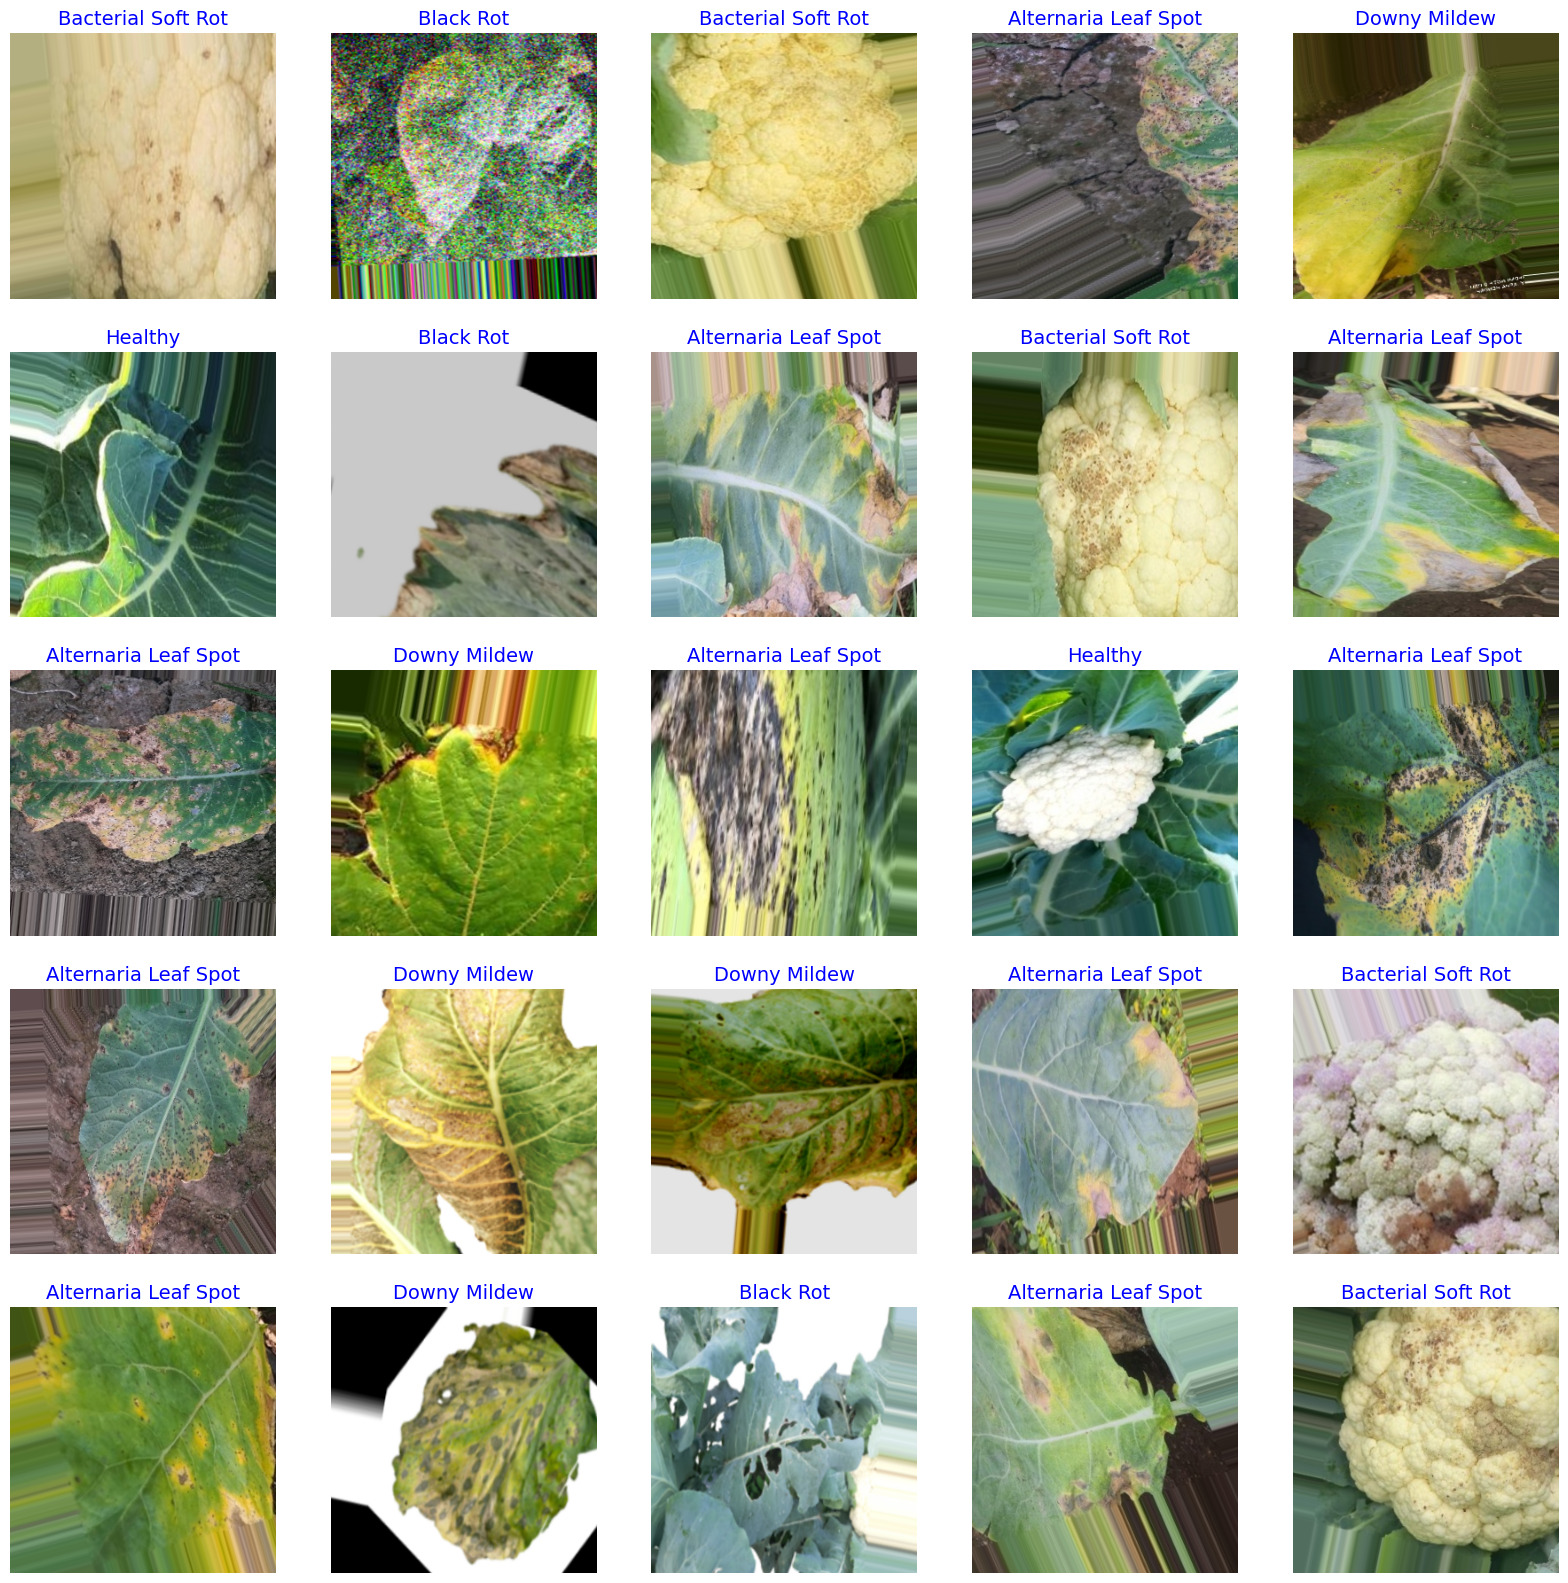

In [11]:
def show_image_samples(gen ):
    t_dict=gen.class_indices
    classes=list(t_dict.keys())
    images,labels=next(gen) # get a sample batch from the generator
    plt.figure(figsize=(20, 20))
    length=len(labels)
    if length<25:   #show maximum of 25 images
        r=length
    else:
        r=25
    for i in range(r):
        plt.subplot(5, 5, i + 1)
        image=images[i] /255
        plt.imshow(image)
        index=np.argmax(labels[i])
        class_name=classes[index]
        plt.title(class_name, color='blue', fontsize=14)
        plt.axis('off')
    plt.show()

show_image_samples(train_gen )

<a id="model"></a>
# <center>Create a model using transfer learning with EfficientNetB3</center>
### NOTE experts advise you make the base model initially not trainable. Then train for some number of epochs
### then fine tune model by making base model trainable and run more epochs
### I have found this to be WRONG!!!!
### Making the base model trainable from the outset leads to faster convegence and a lower validation loss
### for the same number of total epochs!

In [12]:
img_shape = (img_size[0], img_size[1], 3)
model_name = 'EfficientNetB3'

print(f'Building {model_name} model...')

# Create base model
base_model = tf.keras.applications.efficientnet.EfficientNetB3(
    include_top=False,
    weights="imagenet",
    input_shape=img_shape,
    pooling='max'
)

base_model.trainable = True

# Build model with MODERATE regularization
x = base_model.output
x = BatchNormalization(axis=-1, momentum=0.99, epsilon=0.001)(x)

# Add intermediate layer for better feature learning
x = Dense(512, activation='relu',
          kernel_regularizer=regularizers.l2(0.001))(x)
x = Dropout(rate=.45, seed=123)(x)

x = Dense(256, activation='relu',
          kernel_regularizer=regularizers.l2(0.001))(x)
x = Dropout(rate=.35, seed=123)(x)

# Output layer MUST be float32 for mixed precision
output = Dense(class_count, activation='softmax', dtype='float32', name='predictions')(x)

model = Model(inputs=base_model.input, outputs=output)

# Compile model with lower initial learning rate
lr = 0.0005  # Reduced from 0.001 for more stable training
model.compile(
    Adamax(learning_rate=lr),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print(f'\n✓ Model compiled with learning rate: {lr}')
print(f'  Total parameters: {model.count_params():,}')
model.summary()

Building EfficientNetB3 model...
43941136/43941136 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step

✓ Model compiled with learning rate: 0.0005
  Total parameters: 11,709,236


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 300, 300,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling           │ (None, 300, 300,  │          0 │ input_layer[0][0] │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ normalization       │ (None, 300, 300,  │          7 │ rescaling[0][0]   │
│ (Normalization)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_1         │ (None, 300, 300,  │          0 │ normalization[0]… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv_pad       │ (None, 301, 301,  │          0 │ rescaling_1[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv (Conv2D)  │ (None, 150, 150,  │      1,080 │ stem_conv_pad[0]… │
│                     │ 40)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_bn             │ (None, 150, 150,  │        160 │ stem_conv[0][0]   │
│ (BatchNormalizatio… │ 40)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_activation     │ (None, 150, 150,  │          0 │ stem_bn[0][0]     │
│ (Activation)        │ 40)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_dwconv      │ (None, 150, 150,  │        360 │ stem_activation[… │
│ (DepthwiseConv2D)   │ 40)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_bn          │ (None, 150, 150,  │        160 │ block1a_dwconv[0… │
│ (BatchNormalizatio… │ 40)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_activation  │ (None, 150, 150,  │          0 │ block1a_bn[0][0]  │
│ (Activation)        │ 40)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_squeeze  │ (None, 40)        │          0 │ block1a_activati… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reshape  │ (None, 1, 1, 40)  │          0 │ block1a_se_squee… │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reduce   │ (None, 1, 1, 10)  │        410 │ block1a_se_resha… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_expand   │ (None, 1, 1, 40)  │        440 │ block1a_se_reduc… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_excite   │ (None, 150, 150,  │          0 │ block1a_activati… │
│ (Multiply)          │ 40)               │            │ block1a_se_expan… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_project_co… │ (None, 150, 150,  │        960 │ block1a_se_excit

 Total params: 11,709,236 (44.67 MB)

 Trainable params: 11,618,861 (44.32 MB)

 Non-trainable params: 90,375 (353.03 KB)

<a id="callback"></a>
# <center>Create a custom Keras callback to continue and optionally set LR or halt training</center>
The LR_ASK callback is a convenient callback that allows you to continue training for ask_epoch more epochs or to halt training.  
If you elect to continue training for more epochs you are given the option to retain the current learning rate (LR) or to  
enter a new value for the learning rate. The form of use is:  
ask=LR_ASK(model,epochs, ask_epoch) where:  
* model is a string which is the name of your compiled model
* epochs is an integer which is the number of epochs to run specified in model.fit
* ask_epoch is an integer. If ask_epoch is set to a value say 5 then the model will train for 5 epochs.  
  then the user is ask to enter H to halt training, or enter an inter value. For example if you enter 4  
  training will continue for 4 more epochs to epoch 9 then you will be queried again. Once you enter an  
  integer value you are prompted to press ENTER to continue training using the current learning rate  
  or to enter a new value for the learning rate.  
  
 At the end of training the model weights are set to the weights for the epoch that achieved the lowest validation loss

In [13]:
class LR_ASK(keras.callbacks.Callback):
    def __init__ (self, model, epochs,  ask_epoch): # initialization of the callback
        super(LR_ASK, self).__init__()
        self.user_model=model  # Changed from self.model to self.user_model
        self.ask_epoch=ask_epoch
        self.epochs=epochs
        self.ask=True # if True query the user on a specified epoch
        self.lowest_vloss=np.inf
        self.best_weights=self.user_model.get_weights() # Changed to self.user_model
        self.best_epoch=1


    def on_train_begin(self, logs=None): # this runs on the beginning of training
        if self.ask_epoch == 0:
            print('you set ask_epoch = 0, ask_epoch will be set to 1', flush=True)
            self.ask_epoch=1
        if self.ask_epoch >= self.epochs: # you are running for epochs but ask_epoch>epochs
            print('ask_epoch >= epochs, will train for ', epochs, ' epochs', flush=True)
            self.ask=False # do not query the user
        if self.epochs == 1:
            self.ask=False # running only for 1 epoch so do not query user
        else:
            print('Training will proceed until epoch', ask_epoch,' then you will be asked to')
            print(' enter H to halt training or enter an integer for how many more epochs to run then be asked again')
        self.start_time= time.time() # set the time at which training started

    def on_train_end(self, logs=None):   # runs at the end of training
        print('loading model with weights from epoch ', self.best_epoch)
        self.user_model.set_weights(self.best_weights) # Changed to self.user_model
        tr_duration=time.time() - self.start_time   # determine how long the training cycle lasted
        hours = tr_duration // 3600
        minutes = (tr_duration - (hours * 3600)) // 60
        seconds = tr_duration - ((hours * 3600) + (minutes * 60))
        msg = f'training elapsed time was {str(hours)} hours, {minutes:4.1f} minutes, {seconds:4.2f} seconds)'
        print (msg, flush=True) # print out training duration time

    def on_epoch_end(self, epoch, logs=None):  # method runs on the end of each epoch
        v_loss=logs.get('val_loss')  # get the validation loss for this epoch
        if v_loss< self.lowest_vloss:
            self.lowest_vloss=v_loss
            self.best_weights=self.user_model.get_weights() # Changed to self.user_model
            self.best_epoch=epoch + 1
            print (f'\n validation loss of {v_loss:7.4f} is below lowest loss, saving weights from epoch {str(epoch + 1):3s} as best weights')
        else:
            print (f'\n validation loss of {v_loss:7.4f} is above lowest loss of {self.lowest_vloss:7.4f} keeping weights from epoch {str(self.best_epoch)} as best weights')

        if self.ask: # are the conditions right to query the user?
            if epoch + 1 ==self.ask_epoch: # is this epoch the one for quering the user?
                print('\n Enter H to end training or  an integer for the number of additional epochs to run then ask again')
                ans=input()

                if ans == 'H' or ans =='h' or ans == '0': # quit training for these conditions
                    print ('you entered ', ans, ' Training halted on epoch ', epoch+1, ' due to user input\n', flush=True)
                    self.model.stop_training = True # halt training (this self.model is the Keras callback's model)
                else: # user wants to continue training
                    self.ask_epoch += int(ans)
                    if self.ask_epoch > self.epochs:
                        print('\nYou specified maximum epochs of as ', self.epochs, ' cannot train for ', self.ask_epoch, flush =True)
                    else:
                        print ('you entered ', ans, ' Training will continue to epoch ', self.ask_epoch, flush=True)
                        # Fixed: Changed from .lr to .learning_rate
                        lr=float(tf.keras.backend.get_value(self.user_model.optimizer.learning_rate))
                        print(f'current LR is  {lr:7.5f}  hit enter to keep  this LR or enter a new LR')
                        ans=input(' ')
                        if ans =='':
                            print (f'keeping current LR of {lr:7.5f}')
                        else:
                            new_lr=float(ans)
                            # Fixed: Changed from .lr to .learning_rate
                            tf.keras.backend.set_value(self.user_model.optimizer.learning_rate, new_lr)
                            print(' changing LR to ', ans)

<a id="callbacks"></a>
# <center>Instantiate custom callback

In [14]:
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau

epochs = 50  # Increased for better convergence

# Save best model to Google Drive
checkpoint = ModelCheckpoint(
    '/content/drive/MyDrive/best_cauliflower_model.h5',
    monitor='val_loss',
    save_best_only=True,
    verbose=1,
    mode='min'
)

# Reduce learning rate when validation loss plateaus
reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,  # Reduce LR by half
    patience=3,  # Wait 3 epochs before reducing
    min_lr=1e-7,
    verbose=1,
    mode='min'
)

# Stop early if no improvement
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,  # Increased patience for better training
    restore_best_weights=True,
    verbose=1,
    mode='min'
)

callbacks = [checkpoint, reduce_lr, early_stop]
print('✓ Callbacks configured:')

✓ Callbacks configured:


<a id="train"></a>
# <center>Train the model
### Note unlike how you are told it is BETTER to make the base model trainable from the outset
### It will converge faster and have a lower validation losss

In [15]:
print('=' * 80)
print('STARTING TRAINING')
print('=' * 80)
print(f'Epochs: {epochs}')
print(f'Batch size: {batch_size}')
print(f'Steps per epoch: {len(train_gen)}')
print(f'Validation steps: {len(valid_gen)}')
print('=' * 80)

history = model.fit(
    x=train_gen,
    epochs=epochs,
    verbose=1,
    callbacks=callbacks,
    validation_data=valid_gen,
    validation_steps=None,
    shuffle=False,
    initial_epoch=0,
    class_weight=class_weight_dict  # Apply class weights
)

print('\n✓ Training completed!')

STARTING TRAINING
Epochs: 50
Batch size: 40
Steps per epoch: 75
Validation steps: 20


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/50
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 761ms/step - accuracy: 0.4808 - loss: 2.5611
Epoch 1: val_loss improved from inf to 1.66469, saving model to /content/drive/MyDrive/best_cauliflower_model.h5


75/75 ━━━━━━━━━━━━━━━━━━━━ 292s 2s/step - accuracy: 0.4829 - loss: 2.5551 - val_accuracy: 0.8065 - val_loss: 1.6647 - learning_rate: 5.0000e-04
Epoch 2/50
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 775ms/step - accuracy: 0.8556 - loss: 1.5082
Epoch 2: val_loss improved from 1.66469 to 1.27881, saving model to /content/drive/MyDrive/best_cauliflower_model.h5


75/75 ━━━━━━━━━━━━━━━━━━━━ 65s 861ms/step - accuracy: 0.8558 - loss: 1.5076 - val_accuracy: 0.9406 - val_loss: 1.2788 - learning_rate: 5.0000e-04
Epoch 3/50
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 771ms/step - accuracy: 0.9178 - loss: 1.3293
Epoch 3: val_loss improved from 1.27881 to 1.19069, saving model to /content/drive/MyDrive/best_cauliflower_model.h5


...

75/75 ━━━━━━━━━━━━━━━━━━━━ 64s 849ms/step - accuracy: 0.9991 - loss: 0.5290 - val_accuracy: 0.9819 - val_loss: 0.5638 - learning_rate: 5.0000e-04
Epoch 45/50
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 771ms/step - accuracy: 0.9977 - loss: 0.5179
Epoch 45: val_loss improved from 0.56378 to 0.54431, saving model to /content/drive/MyDrive/best_cauliflower_model.h5


75/75 ━━━━━━━━━━━━━━━━━━━━ 64s 850ms/step - accuracy: 0.9977 - loss: 0.5178 - val_accuracy: 0.9858 - val_loss: 0.5443 - learning_rate: 5.0000e-04
Epoch 46/50
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 771ms/step - accuracy: 0.9980 - loss: 0.5015
Epoch 46: val_loss did not improve from 0.54431
75/75 ━━━━━━━━━━━━━━━━━━━━ 60s 798ms/step - accuracy: 0.9979 - loss: 0.5015 - val_accuracy: 0.9794 - val_loss: 0.5476 - learning_rate: 5.0000e-04
Epoch 47/50
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 769ms/step - accuracy: 0.9985 - loss: 0.4883
Epoch 47: val_loss improved from 0.54431 to 0.53028, saving model to /content/drive/MyDrive/best_cauliflower_model.h5


75/75 ━━━━━━━━━━━━━━━━━━━━ 64s 851ms/step - accuracy: 0.9985 - loss: 0.4883 - val_accuracy: 0.9819 - val_loss: 0.5303 - learning_rate: 5.0000e-04
Epoch 48/50
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 782ms/step - accuracy: 0.9942 - loss: 0.4817
Epoch 48: val_loss improved from 0.53028 to 0.50539, saving model to /content/drive/MyDrive/best_cauliflower_model.h5


75/75 ━━━━━━━━━━━━━━━━━━━━ 65s 862ms/step - accuracy: 0.9942 - loss: 0.4816 - val_accuracy: 0.9845 - val_loss: 0.5054 - learning_rate: 5.0000e-04
Epoch 49/50
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 774ms/step - accuracy: 0.9972 - loss: 0.4650
Epoch 49: val_loss improved from 0.50539 to 0.47557, saving model to /content/drive/MyDrive/best_cauliflower_model.h5


75/75 ━━━━━━━━━━━━━━━━━━━━ 64s 854ms/step - accuracy: 0.9972 - loss: 0.4650 - val_accuracy: 0.9884 - val_loss: 0.4756 - learning_rate: 5.0000e-04
Epoch 50/50
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 771ms/step - accuracy: 0.9974 - loss: 0.4522
Epoch 50: val_loss did not improve from 0.47557
75/75 ━━━━━━━━━━━━━━━━━━━━ 60s 799ms/step - accuracy: 0.9974 - loss: 0.4522 - val_accuracy: 0.9819 - val_loss: 0.4834 - learning_rate: 5.0000e-04
Restoring model weights from the end of the best epoch: 49.

✓ Training completed!


<a id="trainingnvalidation"></a>
# <center>Training&Validation Test

In [ ]:
print('\n' + '=' * 80)
print('POST-TRAINING ANALYSIS')
print('=' * 80)

# Check final metrics
final_train_loss = history.history['loss'][-1]
final_train_acc = history.history['accuracy'][-1]
final_val_loss = history.history['val_loss'][-1]
final_val_acc = history.history['val_accuracy'][-1]

print(f'\nFinal Training   - Loss: {final_train_loss:.4f}, Accuracy: {final_train_acc:.4f}')
print(f'Final Validation - Loss: {final_val_loss:.4f}, Accuracy: {final_val_acc:.4f}')

# Find best epoch
best_epoch = np.argmin(history.history['val_loss']) + 1
best_val_loss = np.min(history.history['val_loss'])
best_val_acc = history.history['val_accuracy'][best_epoch - 1]

print(f'\nBest Epoch: {best_epoch}')
print(f'  Validation Loss: {best_val_loss:.4f}')
print(f'  Validation Accuracy: {best_val_acc:.4f}')

# Quick sanity check on a few predictions
print('\n🔍 Quick Prediction Check (first 10 validation samples):')
val_batch, val_labels_batch = next(valid_gen)
val_predictions = model.predict(val_batch[:10])
val_pred_classes = np.argmax(val_predictions, axis=1)
val_class_names = [classes[i] for i in val_pred_classes]
print('Predicted classes:', val_class_names)

unique_preds = np.unique(val_pred_classes)
if len(unique_preds) > 1:
    print('✅ GOOD: Model is predicting MULTIPLE classes (not just Healthy)!')
else:
    print('⚠️ WARNING: Model still predicting only one class. Check training logs.')

print('=' * 80)


POST-TRAINING ANALYSIS

Final Training   - Loss: 0.4473, Accuracy: 0.9977
Final Validation - Loss: 0.4834, Accuracy: 0.9819

Best Epoch: 49
  Validation Loss: 0.4756
  Validation Accuracy: 0.9884

🔍 Quick Prediction Check (first 10 validation samples):
1/1 ━━━━━━━━━━━━━━━━━━━━ 36s 36s/step
Predicted classes: ['Alternaria Leaf Spot', 'Healthy', 'Bacterial Soft Rot', 'Alternaria Leaf Spot', 'Bacterial Soft Rot', 'Black Rot', 'Healthy', 'Healthy', 'Downy Mildew', 'Healthy']
✅ GOOD: Model is predicting MULTIPLE classes (not just Healthy)!


<a id="plot"></a>
# <center>Define a function to plot the training data

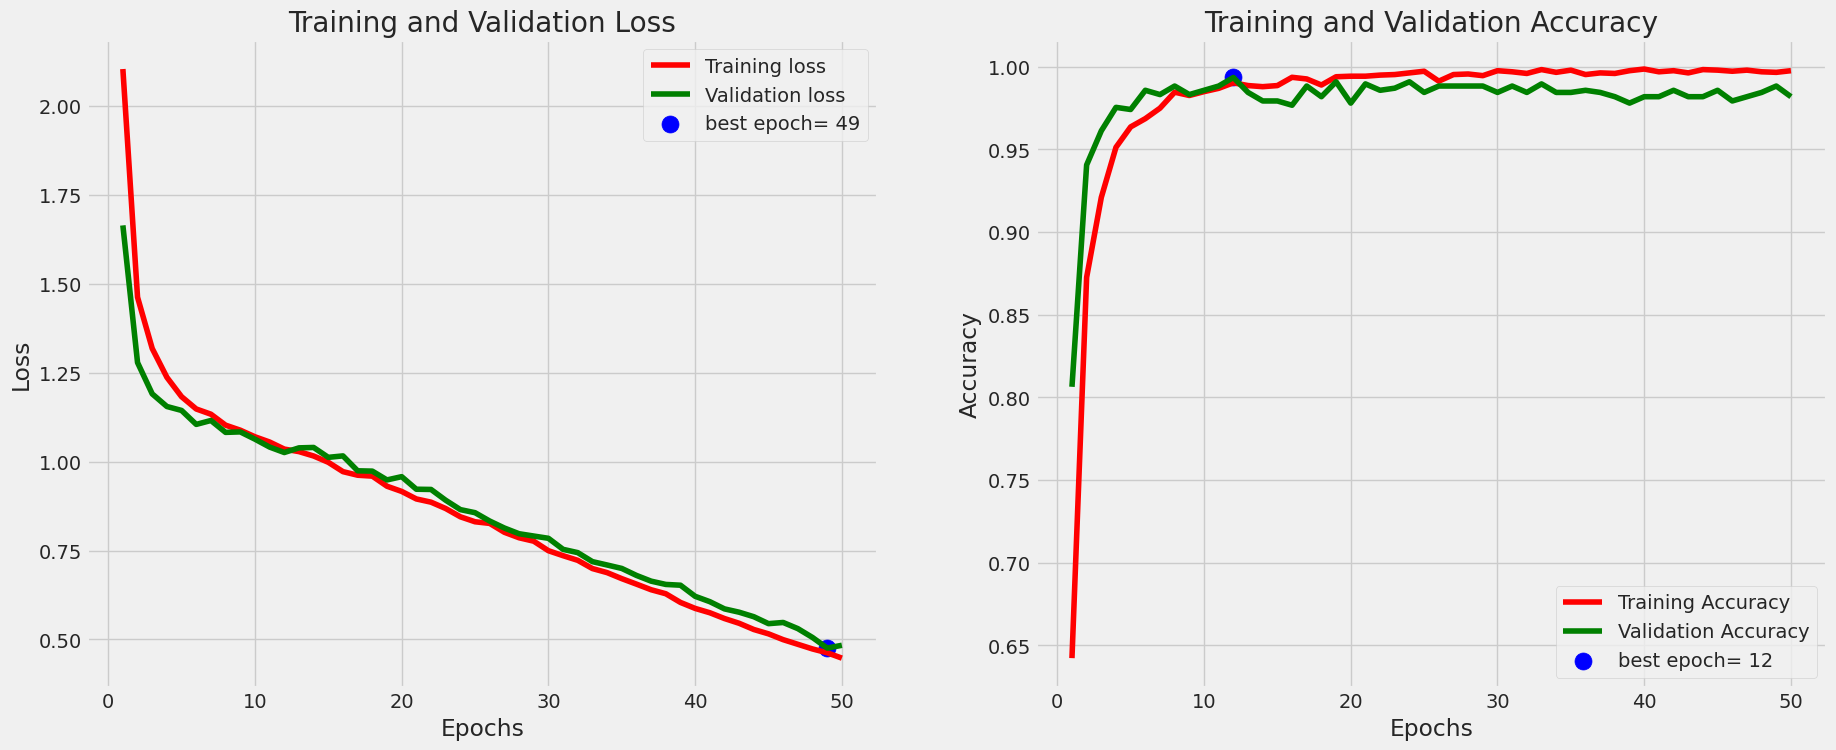

In [19]:
def tr_plot(tr_data, start_epoch):
    #Plot the training and validation data
    tacc=tr_data.history['accuracy']
    tloss=tr_data.history['loss']
    vacc=tr_data.history['val_accuracy']
    vloss=tr_data.history['val_loss']
    Epoch_count=len(tacc)+ start_epoch
    Epochs=[]
    for i in range (start_epoch ,Epoch_count):
        Epochs.append(i+1)
    index_loss=np.argmin(vloss)#  this is the epoch with the lowest validation loss
    val_lowest=vloss[index_loss]
    index_acc=np.argmax(vacc)
    acc_highest=vacc[index_acc]
    plt.style.use('fivethirtyeight')
    sc_label='best epoch= '+ str(index_loss+1 +start_epoch)
    vc_label='best epoch= '+ str(index_acc + 1+ start_epoch)
    fig,axes=plt.subplots(nrows=1, ncols=2, figsize=(20,8))
    axes[0].plot(Epochs,tloss, 'r', label='Training loss')
    axes[0].plot(Epochs,vloss,'g',label='Validation loss' )
    axes[0].scatter(index_loss+1 +start_epoch,val_lowest, s=150, c= 'blue', label=sc_label)
    axes[0].set_title('Training and Validation Loss')
    axes[0].set_xlabel('Epochs')
    axes[0].set_ylabel('Loss')
    axes[0].legend()
    axes[1].plot (Epochs,tacc,'r',label= 'Training Accuracy')
    axes[1].plot (Epochs,vacc,'g',label= 'Validation Accuracy')
    axes[1].scatter(index_acc+1 +start_epoch,acc_highest, s=150, c= 'blue', label=vc_label)
    axes[1].set_title('Training and Validation Accuracy')
    axes[1].set_xlabel('Epochs')
    axes[1].set_ylabel('Accuracy')
    axes[1].legend()
    plt.tight_layout
    plt.show()

tr_plot(history,0)

<a id="result"></a>
# <center>Make Predictions on the test set</a>
### Define a function which takes in a test generator and an integer test_steps
### and generates predictions on the test set including a confusion matric
### and a classification report

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


97/97 ━━━━━━━━━━━━━━━━━━━━ 37s 18ms/step
file  /content/cauliflower_training/cali/Alternaria Leaf Spot/alternaria_leaf_spot_1197.jpg  was an error
file  /content/cauliflower_training/cali/Black Rot/black_rot_118.png  was an error
file  /content/cauliflower_training/cali/Downy Mildew/downy_mildew_0083.png  was an error
file  /content/cauliflower_training/cali/Black Rot/black_rot_281.png  was an error
file  /content/cauliflower_training/cali/Black Rot/black_rot_277.png  was an error
there were 5 errors in 776 tests for an accuracy of  99.36


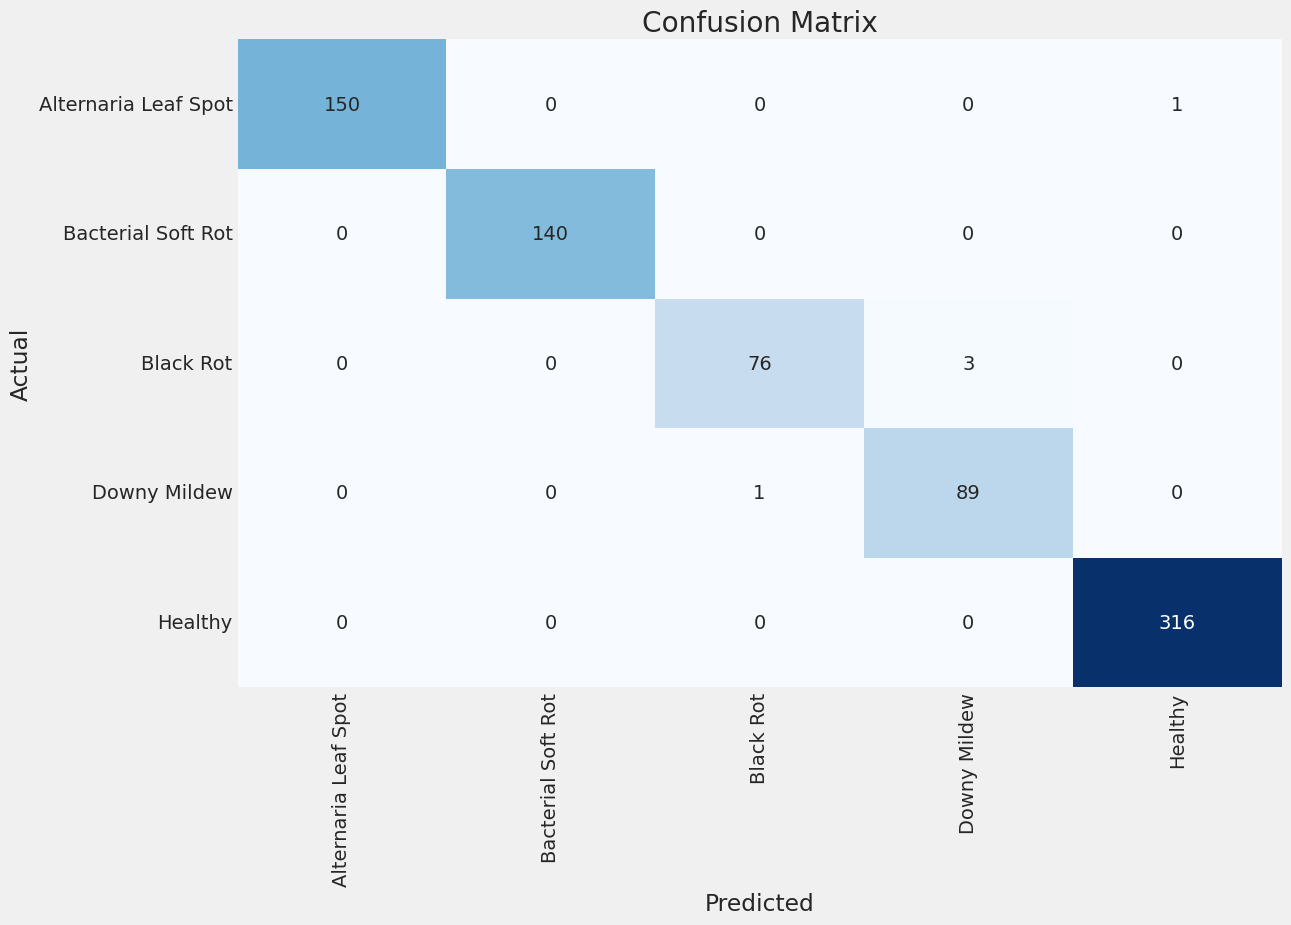

Classification Report:
----------------------
                       precision    recall  f1-score   support

Alternaria Leaf Spot     1.0000    0.9934    0.9967       151
  Bacterial Soft Rot     1.0000    1.0000    1.0000       140
           Black Rot     0.9870    0.9620    0.9744        79
        Downy Mildew     0.9674    0.9889    0.9780        90
             Healthy     0.9968    1.0000    0.9984       316

            accuracy                         0.9936       776
           macro avg     0.9902    0.9889    0.9895       776
        weighted avg     0.9936    0.9936    0.9936       776



In [20]:
def predictor(test_gen, test_steps):
    y_pred= []
    y_true=test_gen.labels
    classes=list(test_gen.class_indices.keys())
    class_count=len(classes)
    errors=0
    preds=model.predict(test_gen, verbose=1)
    tests=len(preds)
    for i, p in enumerate(preds):
        pred_index=np.argmax(p)
        true_index=test_gen.labels[i]  # labels are integer values
        if pred_index != true_index: # a misclassification has occurred
            errors=errors + 1
            file=test_gen.filenames[i]
            print ('file ', file, ' was an error')
        y_pred.append(pred_index)

    acc=( 1-errors/tests) * 100
    print(f'there were {errors} errors in {tests} tests for an accuracy of {acc:6.2f}')
    ypred=np.array(y_pred)
    ytrue=np.array(y_true)
    if class_count <=30:
        cm = confusion_matrix(ytrue, ypred )
        # plot the confusion matrix
        plt.figure(figsize=(12, 8))
        sns.heatmap(cm, annot=True, vmin=0, fmt='g', cmap='Blues', cbar=False)
        plt.xticks(np.arange(class_count)+.5, classes, rotation=90)
        plt.yticks(np.arange(class_count)+.5, classes, rotation=0)
        plt.xlabel("Predicted")
        plt.ylabel("Actual")
        plt.title("Confusion Matrix")
        plt.show()
    clr = classification_report(y_true, y_pred, target_names=classes, digits= 4) # create classification report
    print("Classification Report:\n----------------------\n", clr)
    return errors, tests
errors, tests=predictor(test_gen, test_steps)

<a id="save"></a>
# <center>Save the model

In [21]:
subject='nuts'
acc=str(( 1-errors/tests) * 100)
index=acc.rfind('.')
acc=acc[:index + 3]
save_id= subject + '_' + str(acc) + '.h5'
model_save_loc=os.path.join(working_dir, save_id)
model.save(model_save_loc)
print ('model was saved as ' , model_save_loc )


model was saved as  ./nuts_99.35.h5
